In [14]:
using LinearAlgebra
using Plots

In [15]:
# Função para criar a matriz de Lx na base canônica (Matrix de Vandermonde)
function create_Lx(X,d)
    m = length(X)
    V = zeros(m, d + 1)
    for j in 0:d
        V[:, j+1] = X.^j
    end
    return V
end

function create_Rxd(A)
    # A fórmula como vimos é ((A^T)A)^(-1)A^T
    return inv(A' * A) * A'
end

nothing

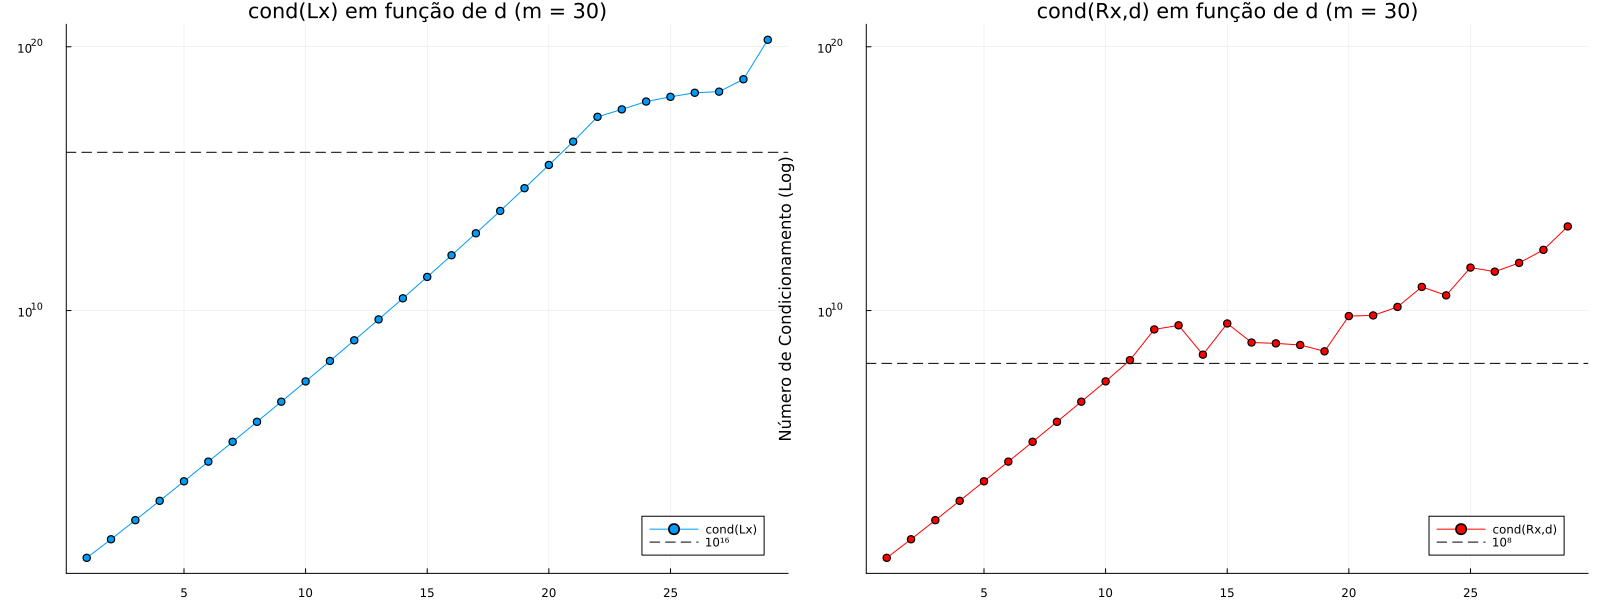

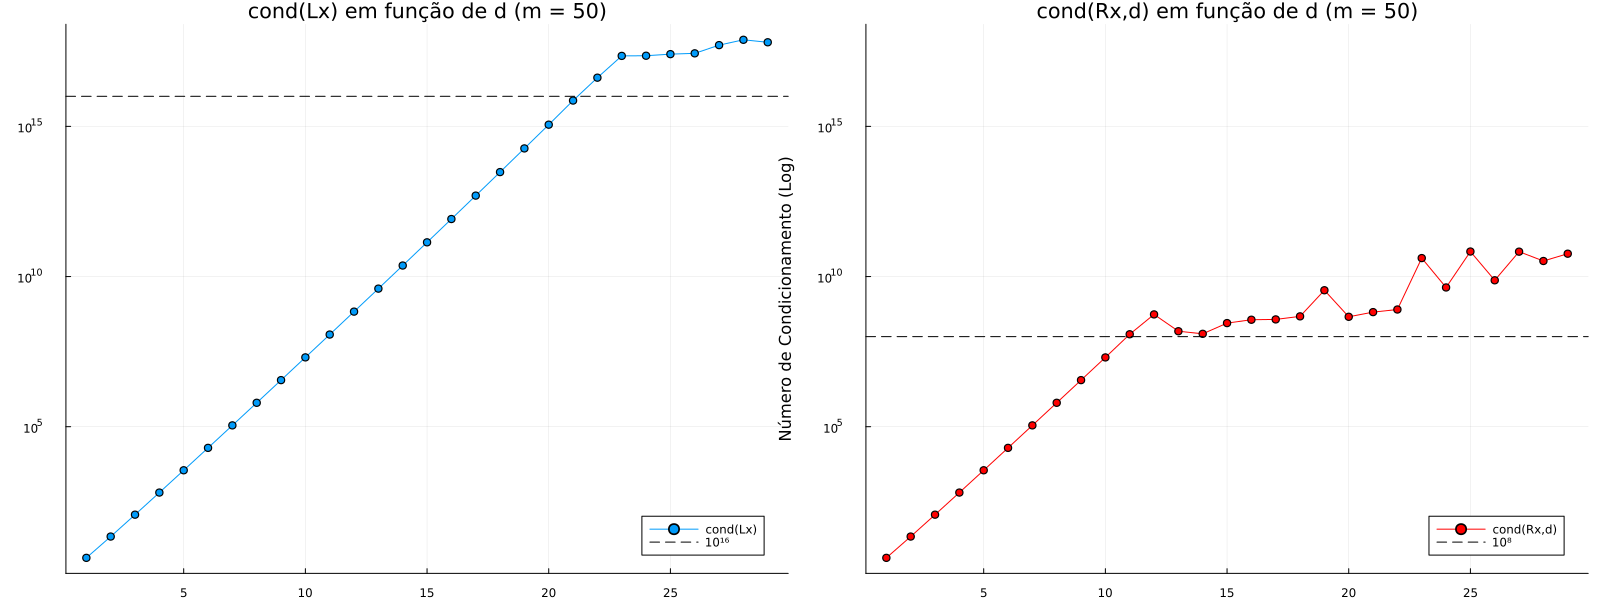

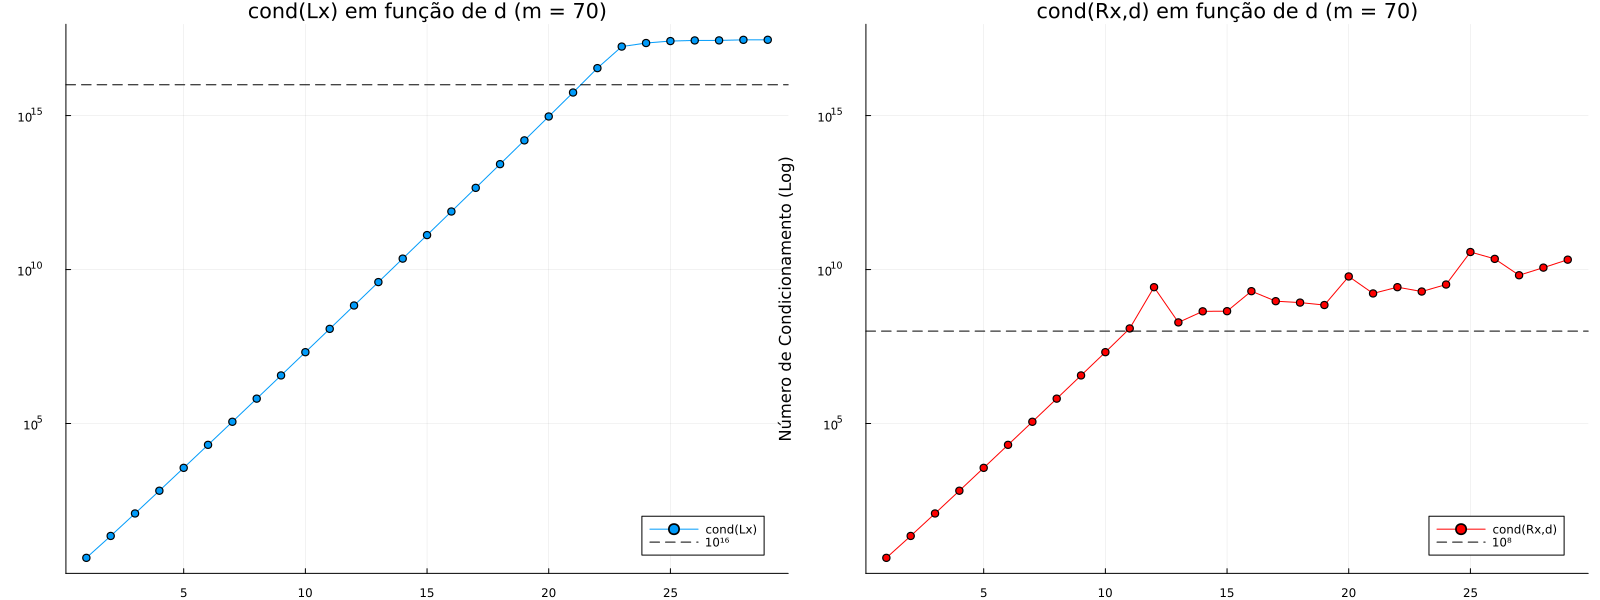

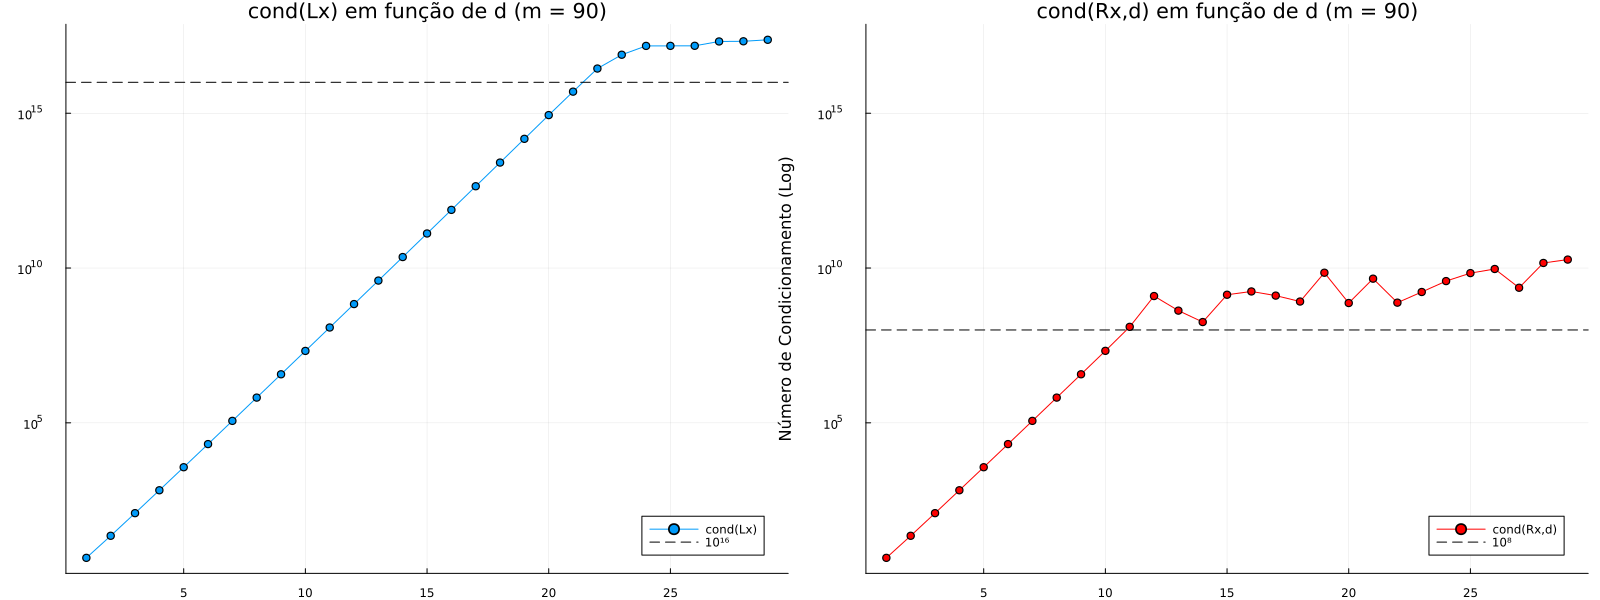

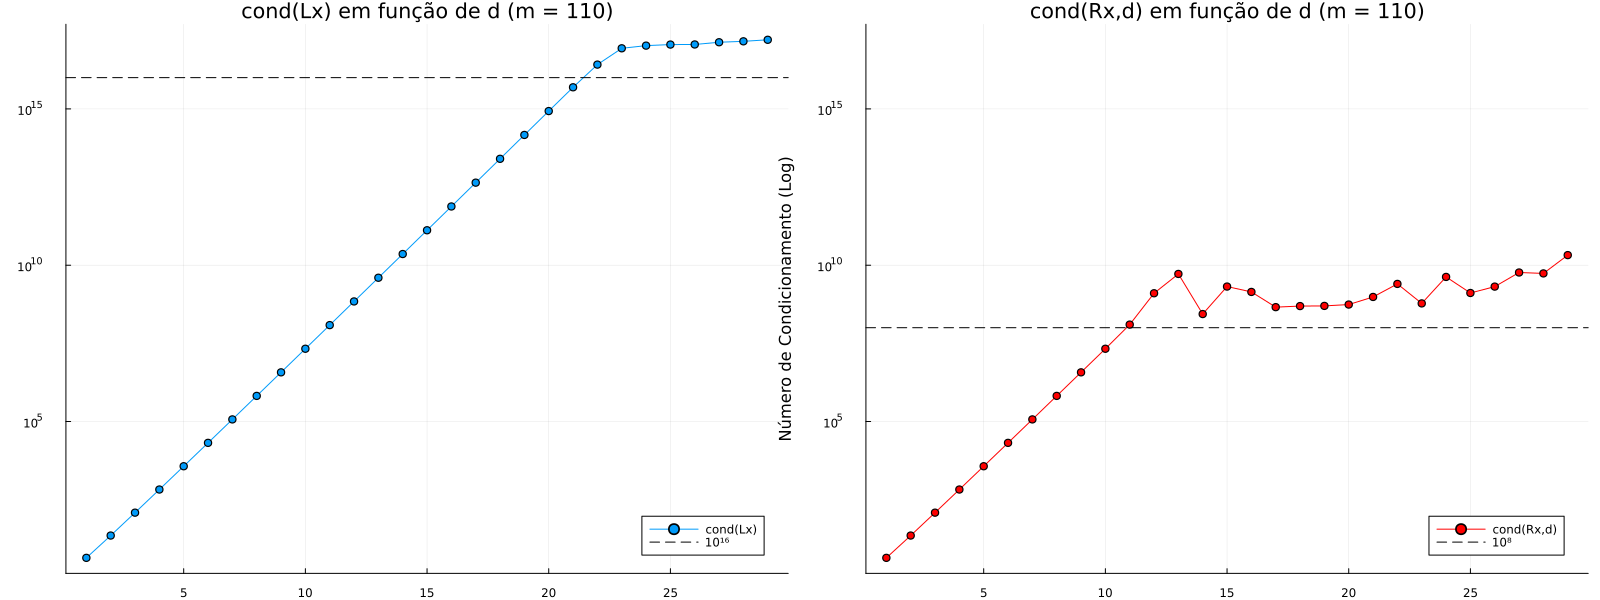

In [29]:
# Vamos criar valores de m e d e ver como o condicionamento varia
m_values = 30:20:110
d_values = 1:29

for m in m_values
    condLx_d = Float64[]
    condR_d = Float64[]
    for d in d_values
        X = range(0, 1, length=m)
        V = create_Lx(X, d)
        R = create_Rxd(V)

        push!(condLx_d, cond(V))
        push!(condR_d, cond(R))
    end

    p1 = plot(d_values, condLx_d, yscale=:log10, label="cond(Lx)", marker=:circle, legend=:bottomright)
    yaxis!(p1, "Número de Condicionamento  (Log)")
    title!(p1, "cond(Lx) em função de d (m = $m)")
    hline!([10^16], label="10¹⁶", linestyle=:dash, color="black")

    p2 = plot(d_values, condR_d, yscale=:log10, label="cond(Rx,d)", marker=:circle, color=:red, legend=:bottomright)
    yaxis!(p2, "Número de Condicionamento (Log)")
    title!(p2, "cond(Rx,d) em função de d (m = $m)")
    hline!([10^8], label="10⁸", linestyle=:dash, color="black")

    p = plot(p1, p2, layout = (1, 2), size = (1600, 600), link=:y)
    display(p)
end

# TODO

Falar como m e d alteram o condicionamento

Explicar por que os gráficos são iguais (SVD)

Explicar por que o gráfico da esquerda deixa de ser igual quando passa de d ~ 12 (K(V^T V) ~10¹⁶)

Calcular a R por QR, para cobrir o erro de condicionamento

In [17]:
# Vamos mudar a forma que calculamos a R, vamos usar a forma (R \ Q*) da fatoração QR de A
# Fazer os gráficos de cima também para a nova forma
# TODO 

function create_Rxd_QR(V)
    F = qr(V)
    Q = Matrix(F.Q) 
    R = F.R
    
    return R \ Q'   
end

nothing


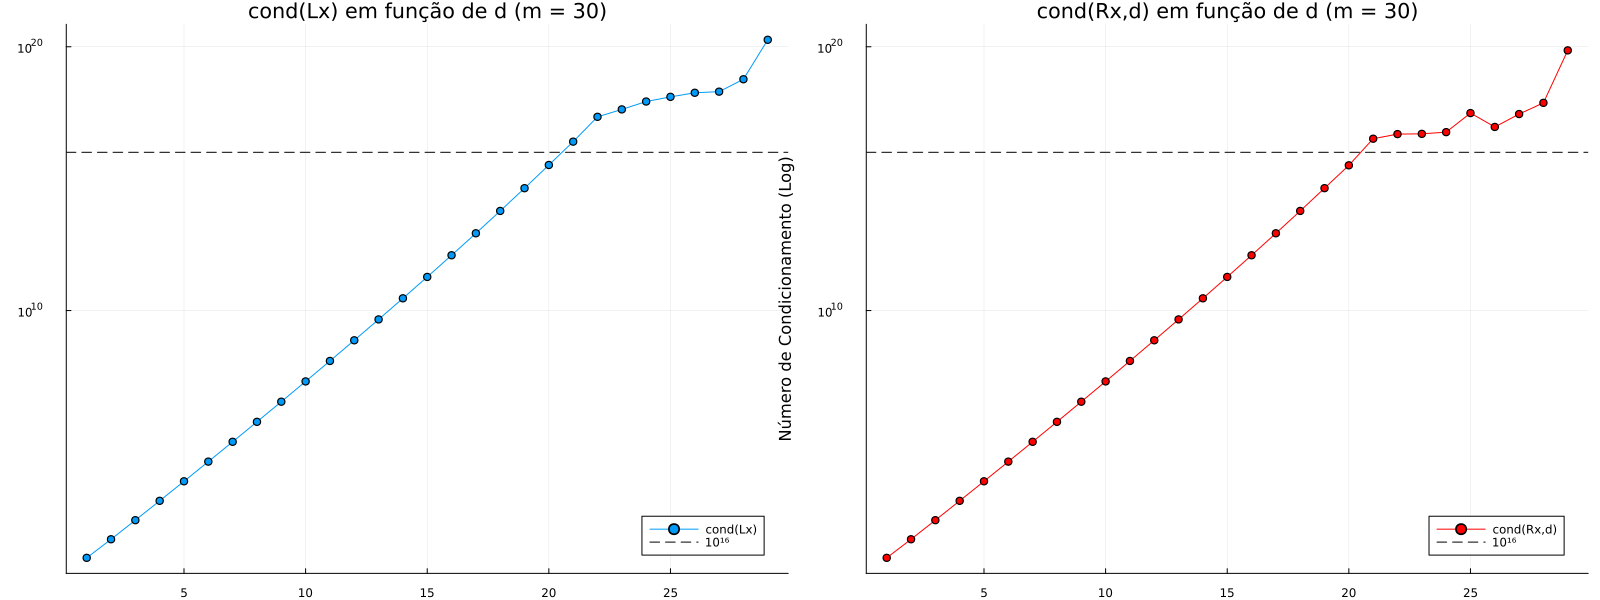

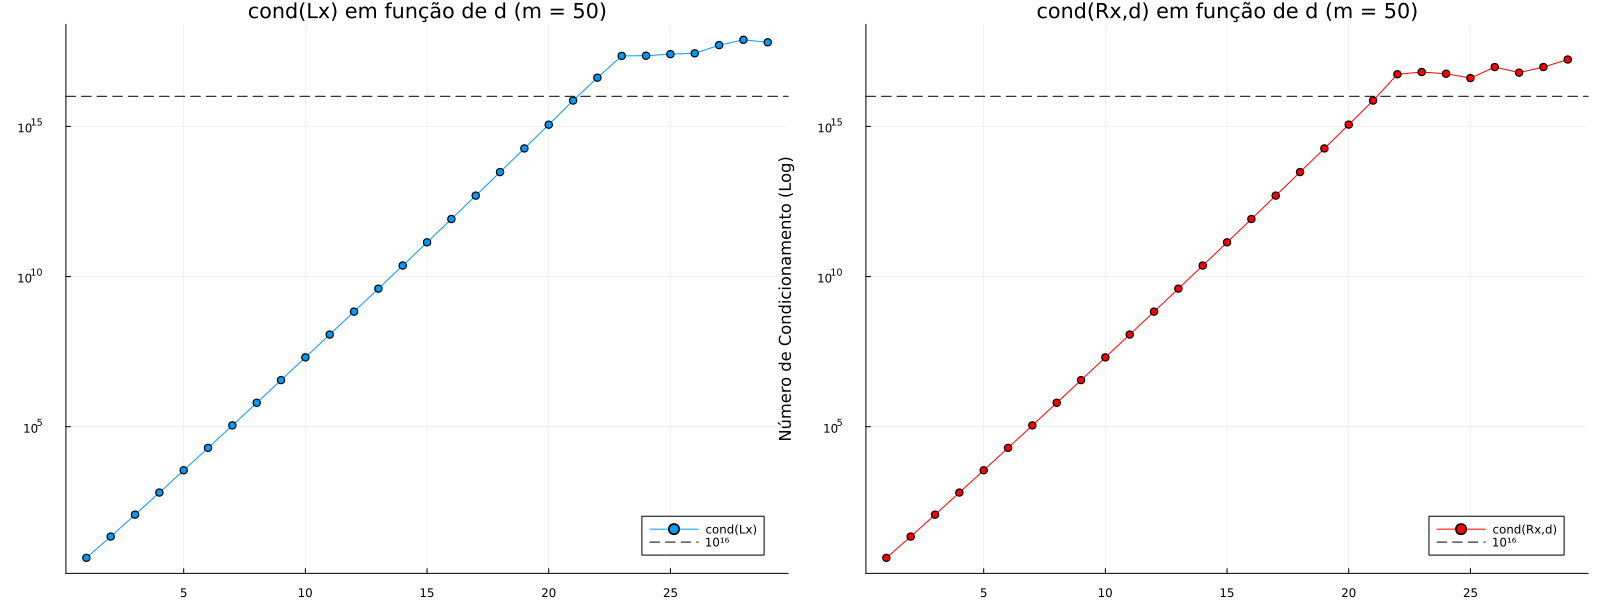

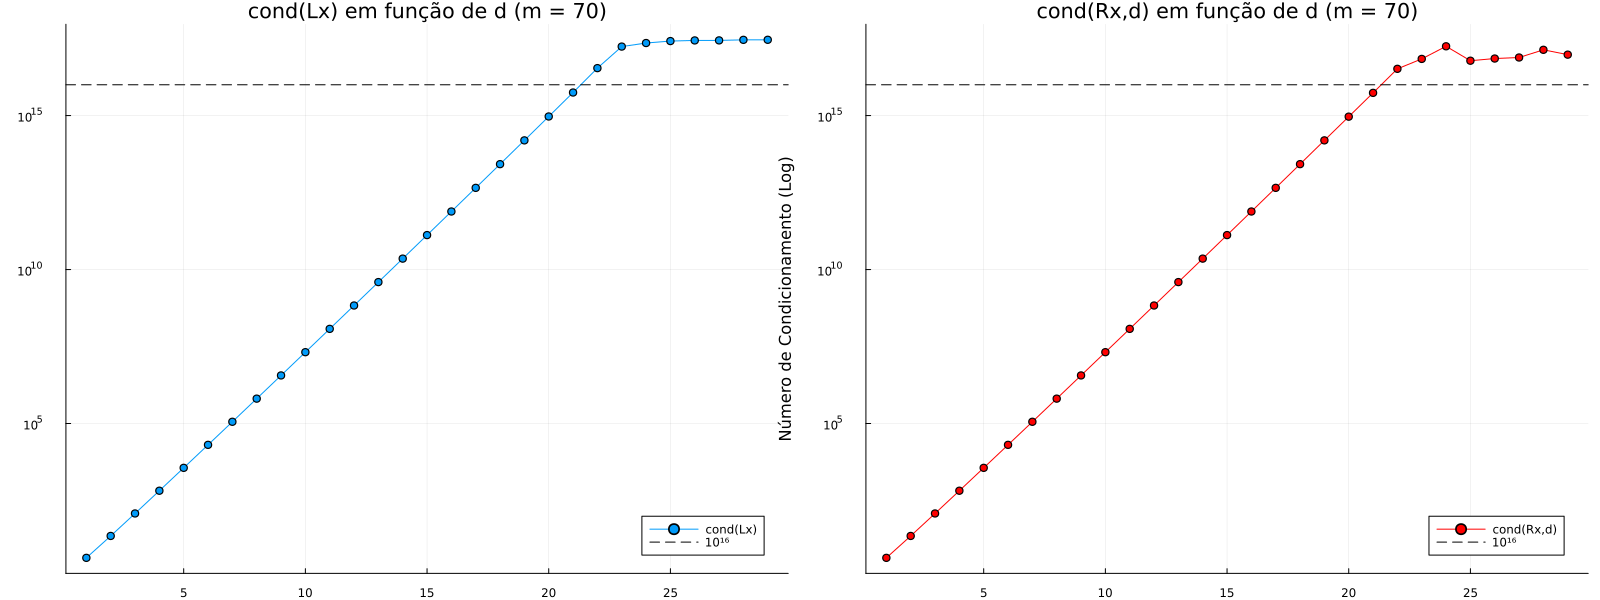

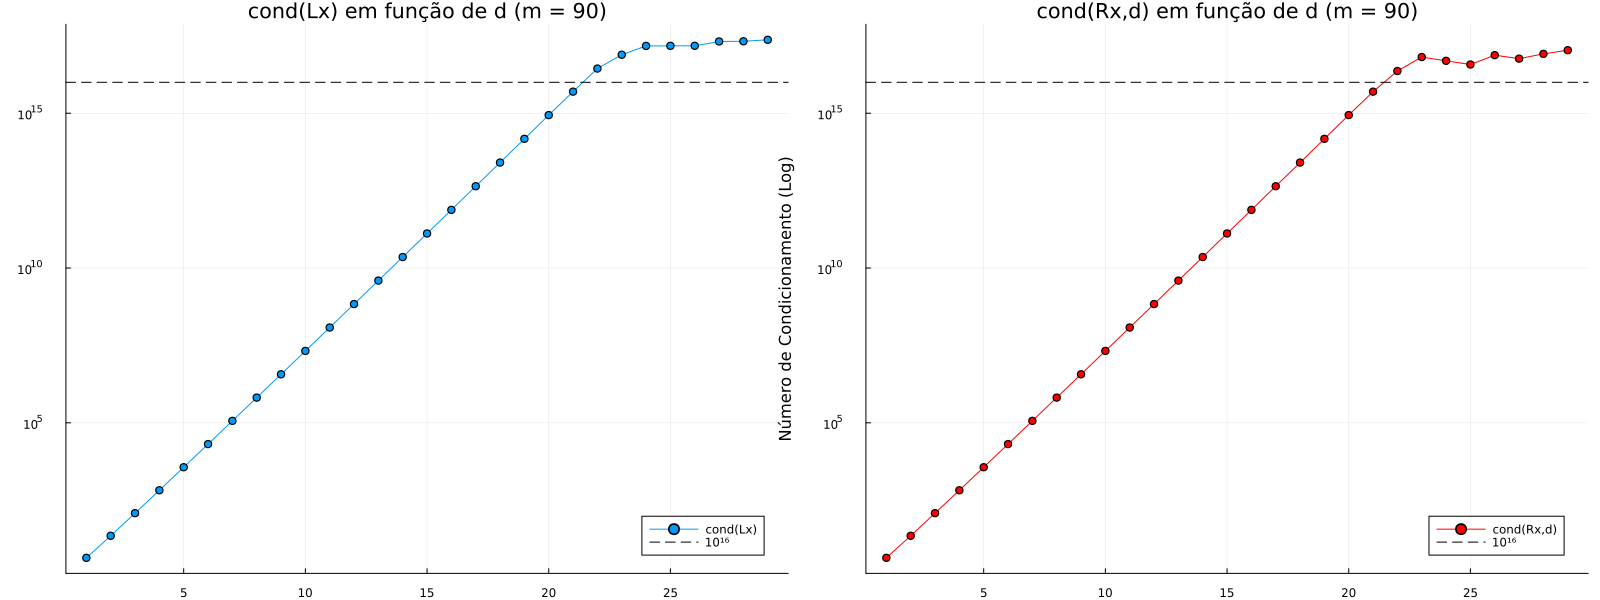

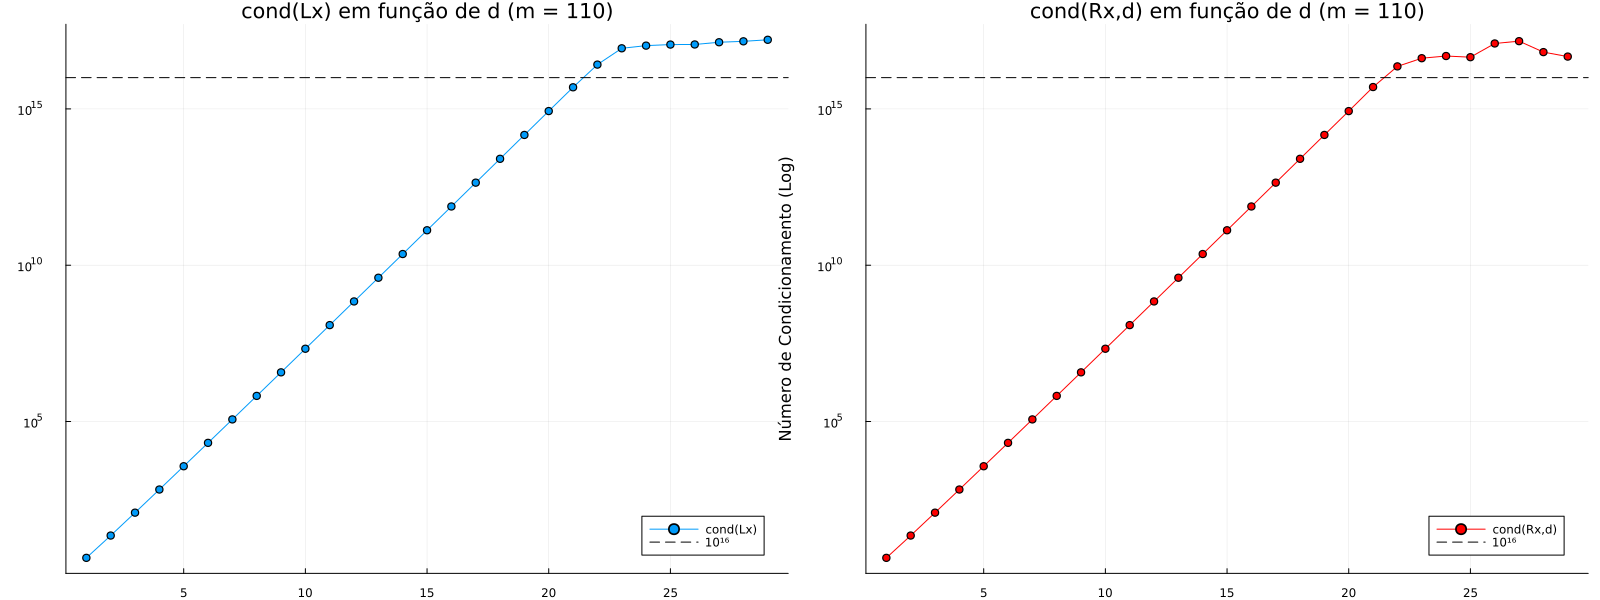

In [28]:
# Vamos agora recalcular o condicionamento usando a R calculada diferente
for m in m_values
    condLx_d = Float64[]
    condR_d = Float64[]
    for d in d_values
        X = range(0, 1, length=m)
        V = create_Lx(X, d)
        R = create_Rxd_QR(V)

        push!(condLx_d, cond(V))
        push!(condR_d, cond(R))
    end

    p1 = plot(d_values, condLx_d, yscale=:log10, label="cond(Lx)", marker=:circle, legend=:bottomright)
    yaxis!(p1, "Número de Condicionamento  (Log)")
    title!(p1, "cond(Lx) em função de d (m = $m)")
    hline!([10^16], label="10¹⁶", linestyle=:dash, color="black")

    p2 = plot(d_values, condR_d, yscale=:log10, label="cond(Rx,d)", marker=:circle, color=:red, legend=:bottomright)
    yaxis!(p2, "Número de Condicionamento (Log)")
    title!(p2, "cond(Rx,d) em função de d (m = $m)")
    hline!([10^16], label="10¹⁶", linestyle=:dash, color="black")

    p = plot(p1, p2, layout = (1, 2), size = (1600, 600), link=:y)
    display(p)
end

# TODO

Falar que deu o que esperavamos (condicionamento realmente fica igual) até 10¹⁶, depois disso começa a ficar diferente pois o cálculo da QR (eu acho) agora tem erro.

In [19]:
# Função para avaliar o i-ésimo polinômio de Lagrange no ponto x
function p(x, i, x_nodes)
    val = 1.0
    for k in 1:length(x_nodes)
        if k != i
            val *= (x - x_nodes[k]) / (x_nodes[i] - x_nodes[k])
        end
    end
    return val
end

function create_Lx_lagrange(X, x_nodes)
    m = length(X)
    colunas = length(x_nodes) # d + 1
    VL = zeros(m, colunas)
    
    # na parte j <= d + 1 a matriz é a Identidade, então só substituimos em vez de calcular 
    for i in 1:colunas
        VL[i, i] = 1.0
    end
    
    # para os pontos restantes, calcular j > d + 1 com a forma do produtório
    for i in 1:colunas
        for j in (colunas + 1):m
            VL[j, i] = p(X[j], i, x_nodes)
        end
    end
    
    return VL
end

nothing

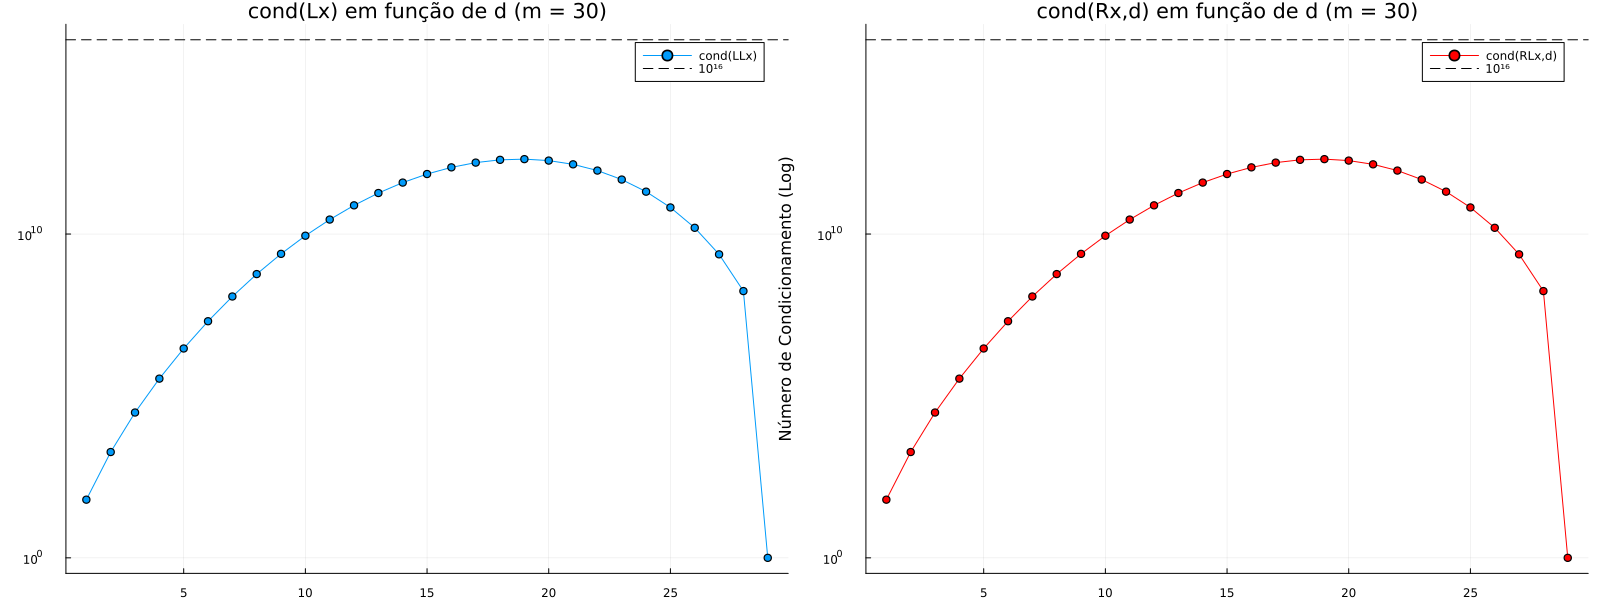

print device already activated


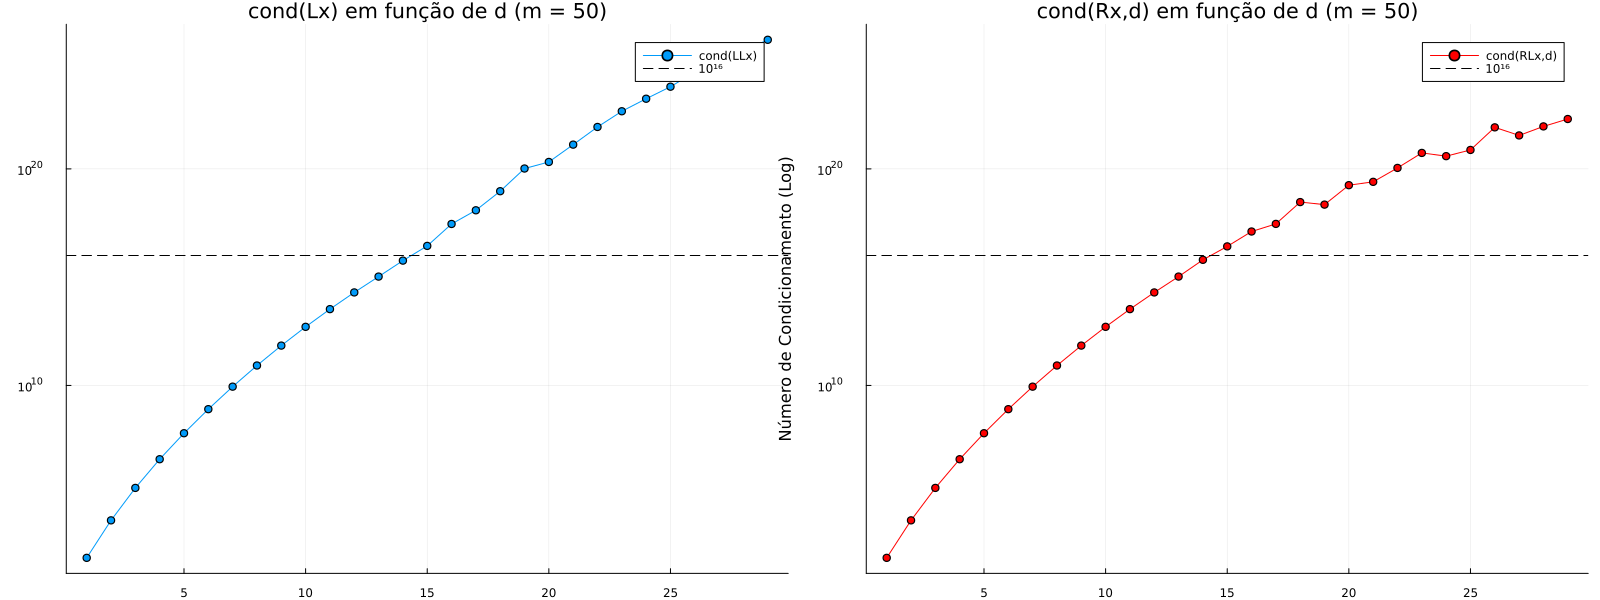

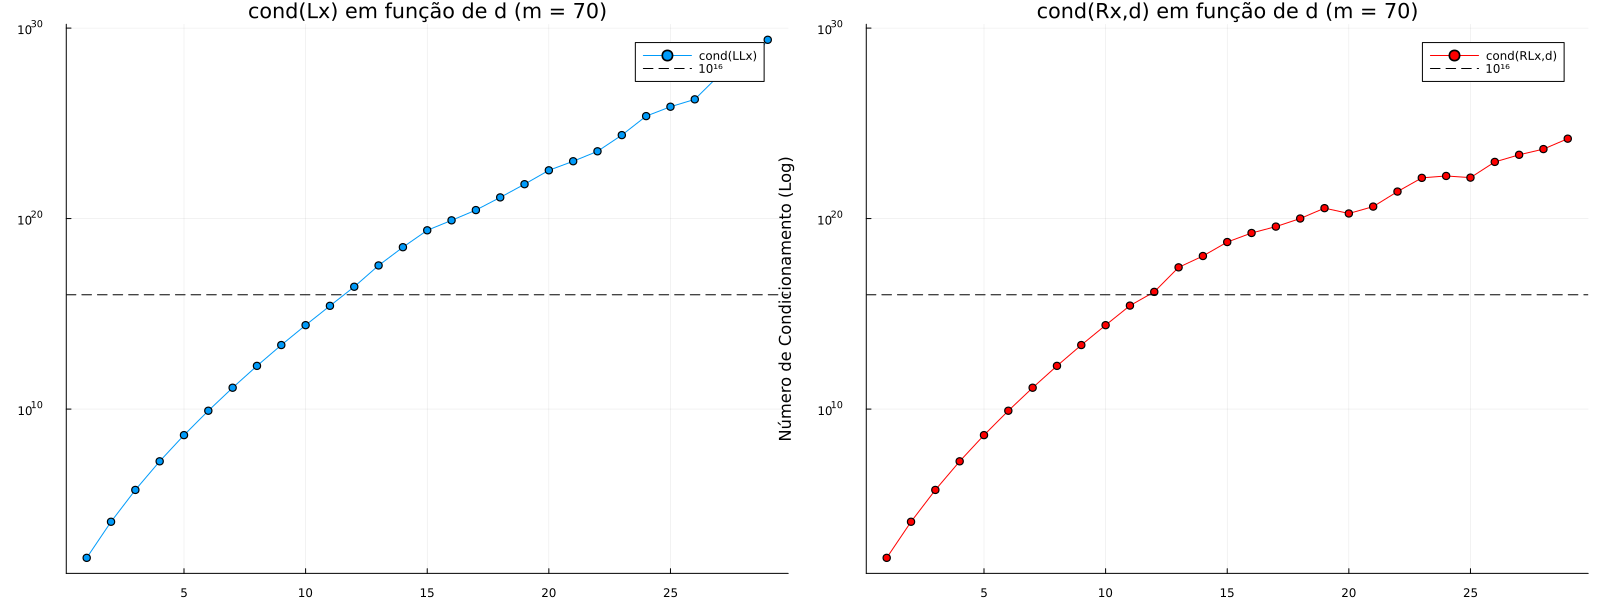

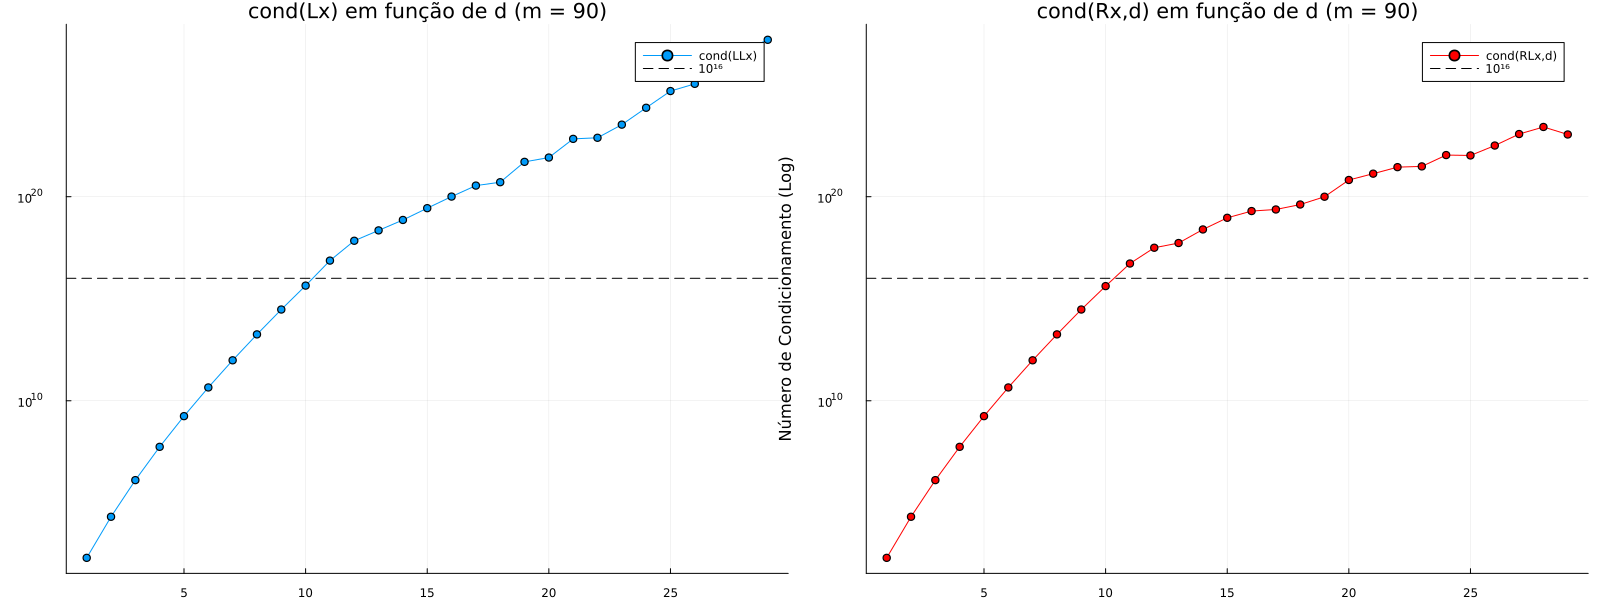

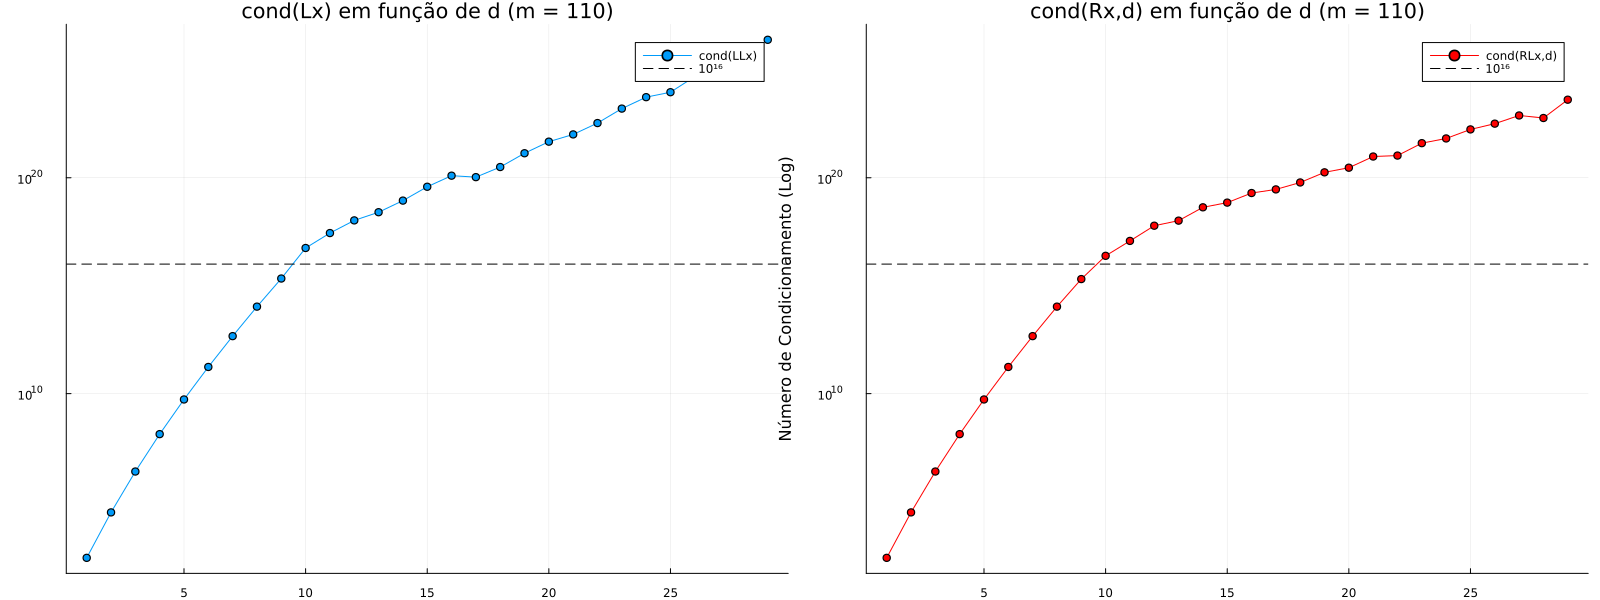

In [ ]:
# Vamos fazer os mesmos gráficos e testes que fizemos para essas matrizes na base canônica 
m_values = 30:20:110
d_values = 1:29

for m in m_values
    condLx_d = Float64[]
    condR_d = Float64[]
    for d in d_values
        X = range(0, 1, length=m)
        # os primeiros d+1 pontos são nossos nós de interpolação
        x_nodes = X[1:(d+1)]

        VL =  create_Lx_lagrange(X, x_nodes)
        RL = create_Rxd_QR(VL)

        push!(condLx_d, cond(VL))
        push!(condR_d, cond(RL))
    end

    p1 = plot(d_values, condLx_d, yscale=:log10, label="cond(LLx)", marker=:circle, legend=:bottomright)
    yaxis!(p1, "Número de Condicionamento  (Log)")
    title!(p1, "cond(Lx) em função de d (m = $m)")
    hline!([10^16], label="10¹⁶", linestyle=:dash, color="black")


    p2 = plot(d_values, condR_d, yscale=:log10, label="cond(RLx,d)", marker=:circle, color="red", legend=:bottomright)
    yaxis!(p2, "Número de Condicionamento (Log)")
    title!(p2, "cond(Rx,d) em função de d (m = $m)")
    hline!([10^16], label="10¹⁶", linestyle=:dash, color="black")

    p = plot(p1, p2, layout = (1, 2), size = (1600, 600), link=:y)
    display(p)
end



# TODO

Explicar a subida: quando d aumenta os polinômios começam a oscilar violentamente nas bordas do intervalo [0,1], como m > d + 1, a matriz avalia os pontos extras de X que caem no meio dessas oscilações.

Descida: Começa a ficar perto da identidade.

Explicar pq m maior aumenta o condicionamento.